In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Setup
- Benchmark A contains five problems (say, id $\in$ [0, 1, 2, 3, 4])
- Strong model X solves three problems: [0, 1, 1, 1, 0]
- Weak model Y solves two problems: [1, 0, 1, 0, 0]

In [10]:
num_samples = 5
strong_result = [0, 1, 1, 1, 0]
weak_result = [1, 0, 1, 0, 0]

x = np.asarray(list(range(num_samples + 1))) / num_samples

In [11]:
def compute_solve_rates(ordering):
    initial_y = sum(weak_result)
    ys = [initial_y]

    current_y = initial_y
    for i in ordering:
        current_y -= weak_result[i]
        current_y += strong_result[i]
        ys.append(current_y)

    return np.asarray(ys) / num_samples

### Routing
Let's say our router predicts confidence of the weak model for each problem as follows: [0.7, 0.4, 0.6, 0.5, 0.3]  
Based on this confidence, we would route our samples starting from the least confident sample, i.e., [4, 1, 3, 2, 0]

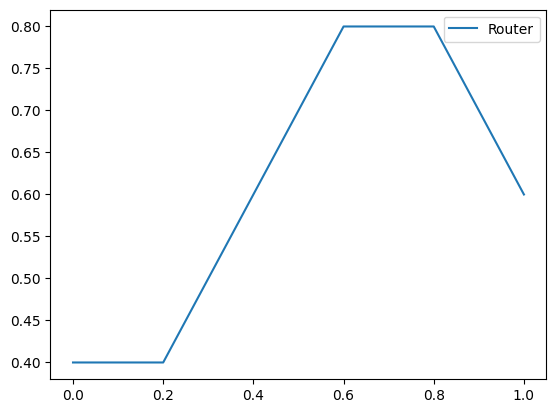

In [18]:
router_ordering = [4, 1, 3, 2, 0]
solve_rate = compute_solve_rates(router_ordering)
plt.plot(x, solve_rate, label='Router')
plt.legend()
plt.show()

### Average Performance Gap Recovered
PGR is computed as the ratio of performance gap recovered at each datapoint

In [ ]:
def compute_discretized_apgr(ordering):
    # approximate by discretization
    initial_y = sum(weak_result)
    ys = [initial_y]

    current_y = initial_y
    for i in ordering:
        current_y -= weak_result[i]
        current_y += strong_result[i]
        ys.append(current_y)

    solve_rates = np.asarray(ys) / num_samples
    
    weak_only_solve_rate = sum(weak_result) / num_samples
    strong_only_solve_rate = sum(strong_result) / num_samples
    performance_gap = strong_only_solve_rate - weak_only_solve_rate
    
    sum_of_pgr = 0.0
    for rate in solve_rates[1:]:
        pgr = (rate - weak_only_solve_rate) / performance_gap
        sum_of_pgr += pgr
    
    return sum_of_pgr / num_samples

In [ ]:
print(f"{compute_discretized_apgr(router_ordering):.3f}")

1.200


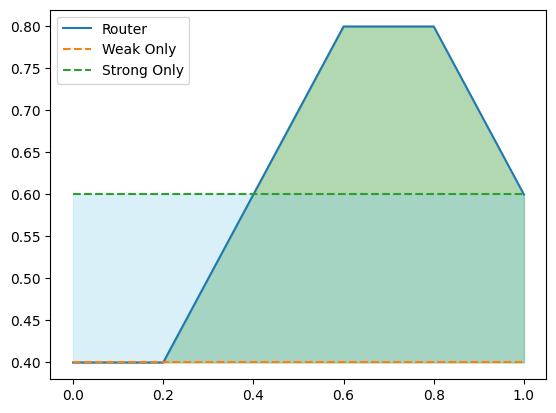

In [66]:
router_solve_rates = compute_solve_rates(router_ordering) 

weak_only_solve_rate = sum(weak_result) / num_samples
weak_only_solve_rates = [weak_only_solve_rate] * len(x)

strong_only_solve_rate = sum(strong_result) / num_samples
strong_only_solve_rates = [strong_only_solve_rate] * len(x)

plt.plot(x, router_solve_rates, label='Router')
plt.plot(x, weak_only_solve_rates, label='Weak Only', linestyle='--')
plt.plot(x, strong_only_solve_rates, label='Strong Only', linestyle='--')

plt.fill_between(x, router_solve_rates, weak_only_solve_rates, color='green', alpha=0.3)
plt.fill_between(x, strong_only_solve_rates, weak_only_solve_rates, color='skyblue', alpha=0.3)

plt.legend()
plt.show()

### Best Scenario
Think of sample sorting problem so that we can maximize our overall solve rate 
1. Routing problem 1 and 3 to the strong model - which are only solved by the strong model, we can increase the overall solve rate
2. Routing problem 2 and 4, which are solved/unsolved by both models, we expect no change in our overall solve rate
3. Finally, as we route problem 0 to the strong model, we lose one previously solved problem
In conclusion, by routing samples in the order of [1, 3, 2, 4, 0], we can achieve the best overall performance

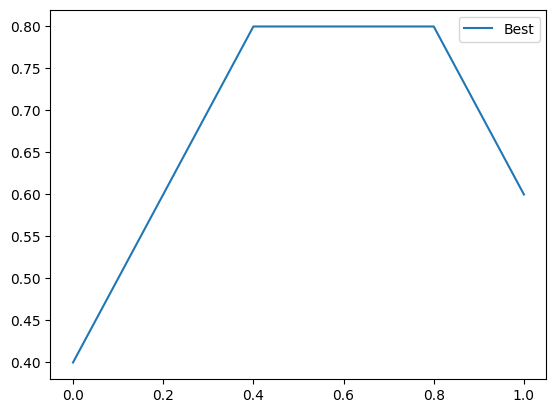

In [16]:
best_ordering = [1, 3, 2, 4, 0]
solve_rate = compute_solve_rates(best_ordering)
plt.plot(x, solve_rate, label='Best')
plt.legend()
plt.show()

### Worst Scenario
Worst scenario is the opposite, we sort samples in the order that the gain from routing a problem from weak model to the strong model is minimized.
One such order would be [0, 4, 2, 3, 1].

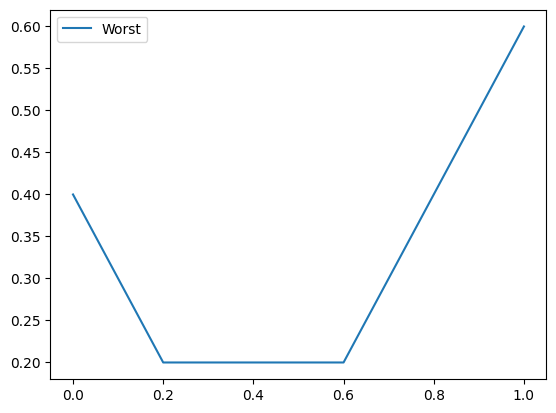

In [ ]:
worst_ordering = [0, 4, 2, 3, 1]
solve_rate = compute_solve_rates(worst_ordering)
plt.plot(x, solve_rate, label='Worst')
plt.legend()
plt.show()

Combining all three curves result in following plot:

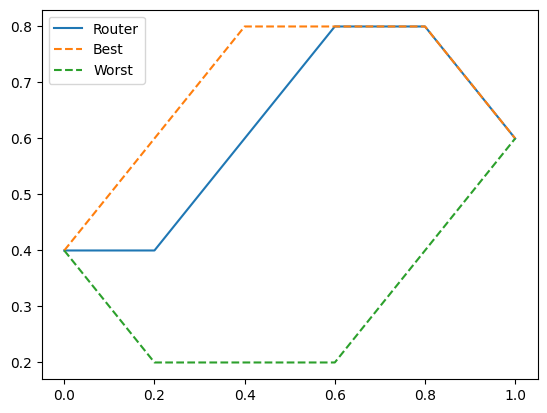

In [ ]:
plt.plot(x, compute_solve_rates(router_ordering), label='Router')
plt.plot(x, compute_solve_rates(best_ordering), label='Best', linestyle='--')
plt.plot(x, compute_solve_rates(worst_ordering), label='Worst', linestyle='--')
plt.legend()
plt.show()

### Router Optimality
Instead of dividing current performance with respect to the performance gap,  
we adopt the performance gap between the best and worst routing scenarios as the divisor.  
By doing so we can safely bound the resulting value in [0, 1] range, regardless of the relative performance of two models.

In [ ]:
def compute_discretized_router_optimality(router_ordering, best_ordering, worst_ordering):
    # approximate by discretization
    initial_y = sum(weak_result)

    router_y, best_y, worst_y = initial_y, initial_y, initial_y
    
    sum_of_ratios = 0.0
    # Within discretized setup, best_y == worst_y after routing all queries to the strong model
    for i in range(num_samples - 1):
        router_y = router_y - weak_result[router_ordering[i]] + strong_result[router_ordering[i]]        
        best_y = best_y - weak_result[best_ordering[i]] + strong_result[best_ordering[i]]        
        worst_y = worst_y - weak_result[worst_ordering[i]] + strong_result[worst_ordering[i]]
        sum_of_ratios += (router_y - worst_y) / (best_y - worst_y)
    
    return sum_of_ratios / (num_samples - 1)

In [ ]:
print(f"{compute_discretized_router_optimality(router_ordering, best_ordering, worst_ordering):.3f}")

0.792


#### Actual Computation of Router Optimality

For the acutal computation, we compute RO by computing the AUC for each curve:
$$ RO(r, b, w) = {{AUC(r) - AUC(w)} \over {AUC(b) - AUC(w)}}$$
where $r, b, w$ stand for the curves of routed/best/worst scenario and $AUC$ is a function that computes the area under curve

In [ ]:
def AUC(x, y):
    assert len(x) == len(y)
    area = 0.0
    for i in range(len(x) - 1):
        area += (x[i + 1] - x[i]) * (y[i + 1] + y[i]) / 2
    return area

def compute_router_optimality(x, router_ordering, best_ordering, worst_ordering):
    initial_y = sum(weak_result) / num_samples

    router_ys, best_ys, worst_ys = [initial_y], [initial_y], [initial_y]
    router_y, best_y, worst_y = initial_y, initial_y, initial_y
    
    for i in range(num_samples):
        router_y = router_y - weak_result[router_ordering[i]] + strong_result[router_ordering[i]]
        router_ys.append(router_y)
        
        best_y = best_y - weak_result[best_ordering[i]] + strong_result[best_ordering[i]]
        best_ys.append(best_y)
        
        worst_y = worst_y - weak_result[worst_ordering[i]] + strong_result[worst_ordering[i]]
        worst_ys.append(worst_y)
    
    auc_router = AUC(x, router_ys)
    auc_best = AUC(x, best_ys)
    auc_worst = AUC(x, worst_ys)
        
    
    return (auc_router - auc_worst) / (auc_best - auc_worst)

In [35]:
print(f"{compute_router_optimality(x, router_ordering, best_ordering, worst_ordering):.3f}")

0.800


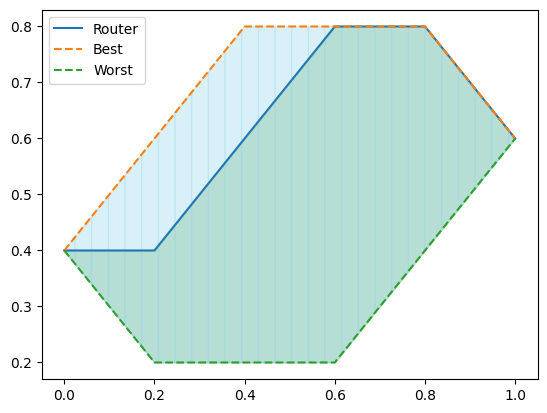

In [70]:
router_solve_rates = compute_solve_rates(router_ordering)
best_solve_rates = compute_solve_rates(best_ordering) 
worst_solve_rates = compute_solve_rates(worst_ordering) 

plt.plot(x, router_solve_rates, label='Router')
plt.plot(x, best_solve_rates, label='Best', linestyle='--')
plt.plot(x, worst_solve_rates, label='Worst', linestyle='--')

plt.fill_between(x, router_solve_rates, worst_solve_rates, color='green', alpha=0.2)

best_poly = plt.fill_between(x, best_solve_rates, worst_solve_rates, color='skyblue', alpha=0.3)
best_poly.set_hatch('|')

plt.legend()
plt.show()